# Final Project  - Data Mining & Data Visualization
Oren Turiel  
Uri Lubetzki  
Noam Frei 314669508

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Define defaults for the images ahead
%matplotlib inline
sns.set(color_codes=True) # settings for seaborn plotting style
sns.set(rc={'figure.figsize':(5,5)}) # settings for seaborn plot sizes

# Load data
df = pd.read_csv("shopper_train.csv")


### Step 1: General overlook of the data

In [2]:
print("Shape: ", df.shape)
df.head()

Shape:  (9864, 20)


,num_admin_pages,admin_duration,num_info_pages,info_duration,num_product_pages,product_duration,bounce_rate,exit_rate,page_value,special_day_score,month,operating_system,browser,region,traffic_type,visitor_type,is_weekend,engagement_score,abandonment_score,high_intent
0,0,0.0,0,0.0,3,13.000000,0.066667,0.133333,0.000000,0.0,NaN,3,2,3,3,Returning_Visitor,0,2.255623,0.100000,0
1,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,NaN,2,2,3,6,Returning_Visitor,0,0.400000,0.200000,0
2,0,0.0,0,0.0,8,101.750000,0.025000,0.075000,0.000000,0.0,Nov,2,2,6,2,NaN,0,5.052920,0.050000,0
3,0,0.0,2,38.2,121,3362.749679,0.025171,0.042322,4.212416,0.0,Jul,1,1,1,3,Returning_Visitor,0,52.048325,0.033747,1
4,2,2.0,0,0.0,0,NaN,0.100000,0.100000,0.000000,0.0,NaN,1,1,3,2,Returning_Visitor,1,0.000000,0.100000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   num_admin_pages    9864 non-null   int64  
 1   admin_duration     9864 non-null   float64
 2   num_info_pages     9864 non-null   int64  
 3   info_duration      9864 non-null   float64
 4   num_product_pages  9864 non-null   int64  
 5   product_duration   9466 non-null   float64
 6   bounce_rate        8707 non-null   float64
 7   exit_rate          9864 non-null   float64
 8   page_value         9368 non-null   float64
 9   special_day_score  9864 non-null   float64
 10  month              8404 non-null   object 
 11  operating_system   9864 non-null   int64  
 12  browser            9864 non-null   int64  
 13  region             9864 non-null   int64  
 14  traffic_type       9864 non-null   int64  
 15  visitor_type       8868 non-null   object 
 16  is_weekend         9864 

we can see that some of the features consists missing values:
product_duration, bounce_rate, page_value, month and visitor_type

Show the ditribution of the data

In [4]:
# filter to calculate only for numeric columns (int or float types)
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

columns_to_remove = [
    'operating_system',
    'browser',
    'region',
    'traffic_type',
]

# remove unwanted columns from the numeric column list
numeric_columns = numeric_columns.drop(columns_to_remove)

# statistics for numeric columns and transpose for convenience
numeric_stat = df[numeric_columns].describe().T

display(numeric_stat)


,count,mean,std,min,25%,50%,75%,max
num_admin_pages,9864.0,2.315998,3.317772,0.0,0.000000,1.000000,4.000000,27.000000
admin_duration,9864.0,80.649453,176.661607,0.0,0.000000,7.000000,94.000000,3398.750000
num_info_pages,9864.0,0.505272,1.280087,0.0,0.000000,0.000000,0.000000,24.000000
info_duration,9864.0,34.850598,143.030197,0.0,0.000000,0.000000,0.000000,2549.375000
num_product_pages,9864.0,31.967153,45.211945,0.0,7.000000,18.000000,38.000000,705.000000
product_duration,9466.0,1210.774075,1995.796241,0.0,181.000000,601.779189,1475.918178,63973.522230
bounce_rate,8707.0,0.022700,0.049304,0.0,0.000000,0.003200,0.017143,0.200000
exit_rate,9864.0,0.043407,0.049013,0.0,0.014286,0.025287,0.050000,0.200000
page_value,9368.0,5.908801,18.376616,0.0,0.000000,0.000000,0.000000,361.763742
special_day_score,9864.0,0.061192,0.198531,0.0,0.000000,0.000000,0.000000,1.000000


In [5]:
# Create a summary DataFrame with metadata for each column
data_summary = pd.DataFrame({
    'Data Type': df.dtypes,  # Data type of each column
    'Missing Values': df.isnull().sum(),  # Number of missing values in each column
    'Missing %': df.isnull().mean() * 100,  # Percentage of missing values in each column
    'Unique Values': df.nunique()  # Number of unique values in each column
})

display(data_summary)  # Display the data summary DataFrame

,Data Type,Missing Values,Missing %,Unique Values
num_admin_pages,int64,0,0.000000,26
admin_duration,float64,0,0.000000,2805
num_info_pages,int64,0,0.000000,16
info_duration,float64,0,0.000000,1064
num_product_pages,int64,0,0.000000,291
product_duration,float64,398,4.034874,7480
bounce_rate,float64,1157,11.729521,1466
exit_rate,float64,0,0.000000,3974
page_value,float64,496,5.028386,2082
special_day_score,float64,0,0.000000,6


In [6]:
# Count how many missing values exist in each row
missing_per_row = df.isnull().sum(axis=1)

# Count rows according to number of missing values
missing_summary = (
    missing_per_row
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns for clarity
missing_summary.columns = ['Number of Missing Values in Row', 'Number of Rows']

display(missing_summary)

,Number of Missing Values in Row,Number of Rows
0,0,6056
1,1,3153
2,2,611
3,3,44


# For Uri & Oren

I am writing here some ideas for continuing the project:
- define threshold for rows which lacks many features. Don't think we need to remove columns but maybe we'll decide to do it.
- I checked already in a code I deleted (perhaps I should write it again) that each column consists of only one data type (nan is float so the columns of object show that they consist of 2 data type but it's OK)
- Plot histograms for the numerical values, and also plot in some way the distribution of the textual values
- Perform sns.boxplot & sns.displot & sns.histplot & plt.pie & sns.countplot & df.groupby for some features
- Take from the lecture the different types of plots which Gonen taught us. (Uri) find the commands for each plot. decide which one of the features fiths every plot.
- decide how to separate between the features and the target ('high_intent' column)
- Probably we will need to normalize to [0,1] part of the features


Flow:
- define each kind of a feature based on ordinal, id, etc.
- decide which kind of plot fits the certain feature
- decide what to delete or fill based on probabilities or corelation.

# Oren
num_admin_pages
admin_duration
num_info_pages
info_duration
num_product_pages
product_duration
bounce_rate
exit_rate
page_value
special_day_score
month
operating_system
browser
region
traffic_type
visitor_type
is_weekend
engagement_score
abandonment_score
high_intent - target. 0/1


I created pie plots for the features which are categorial

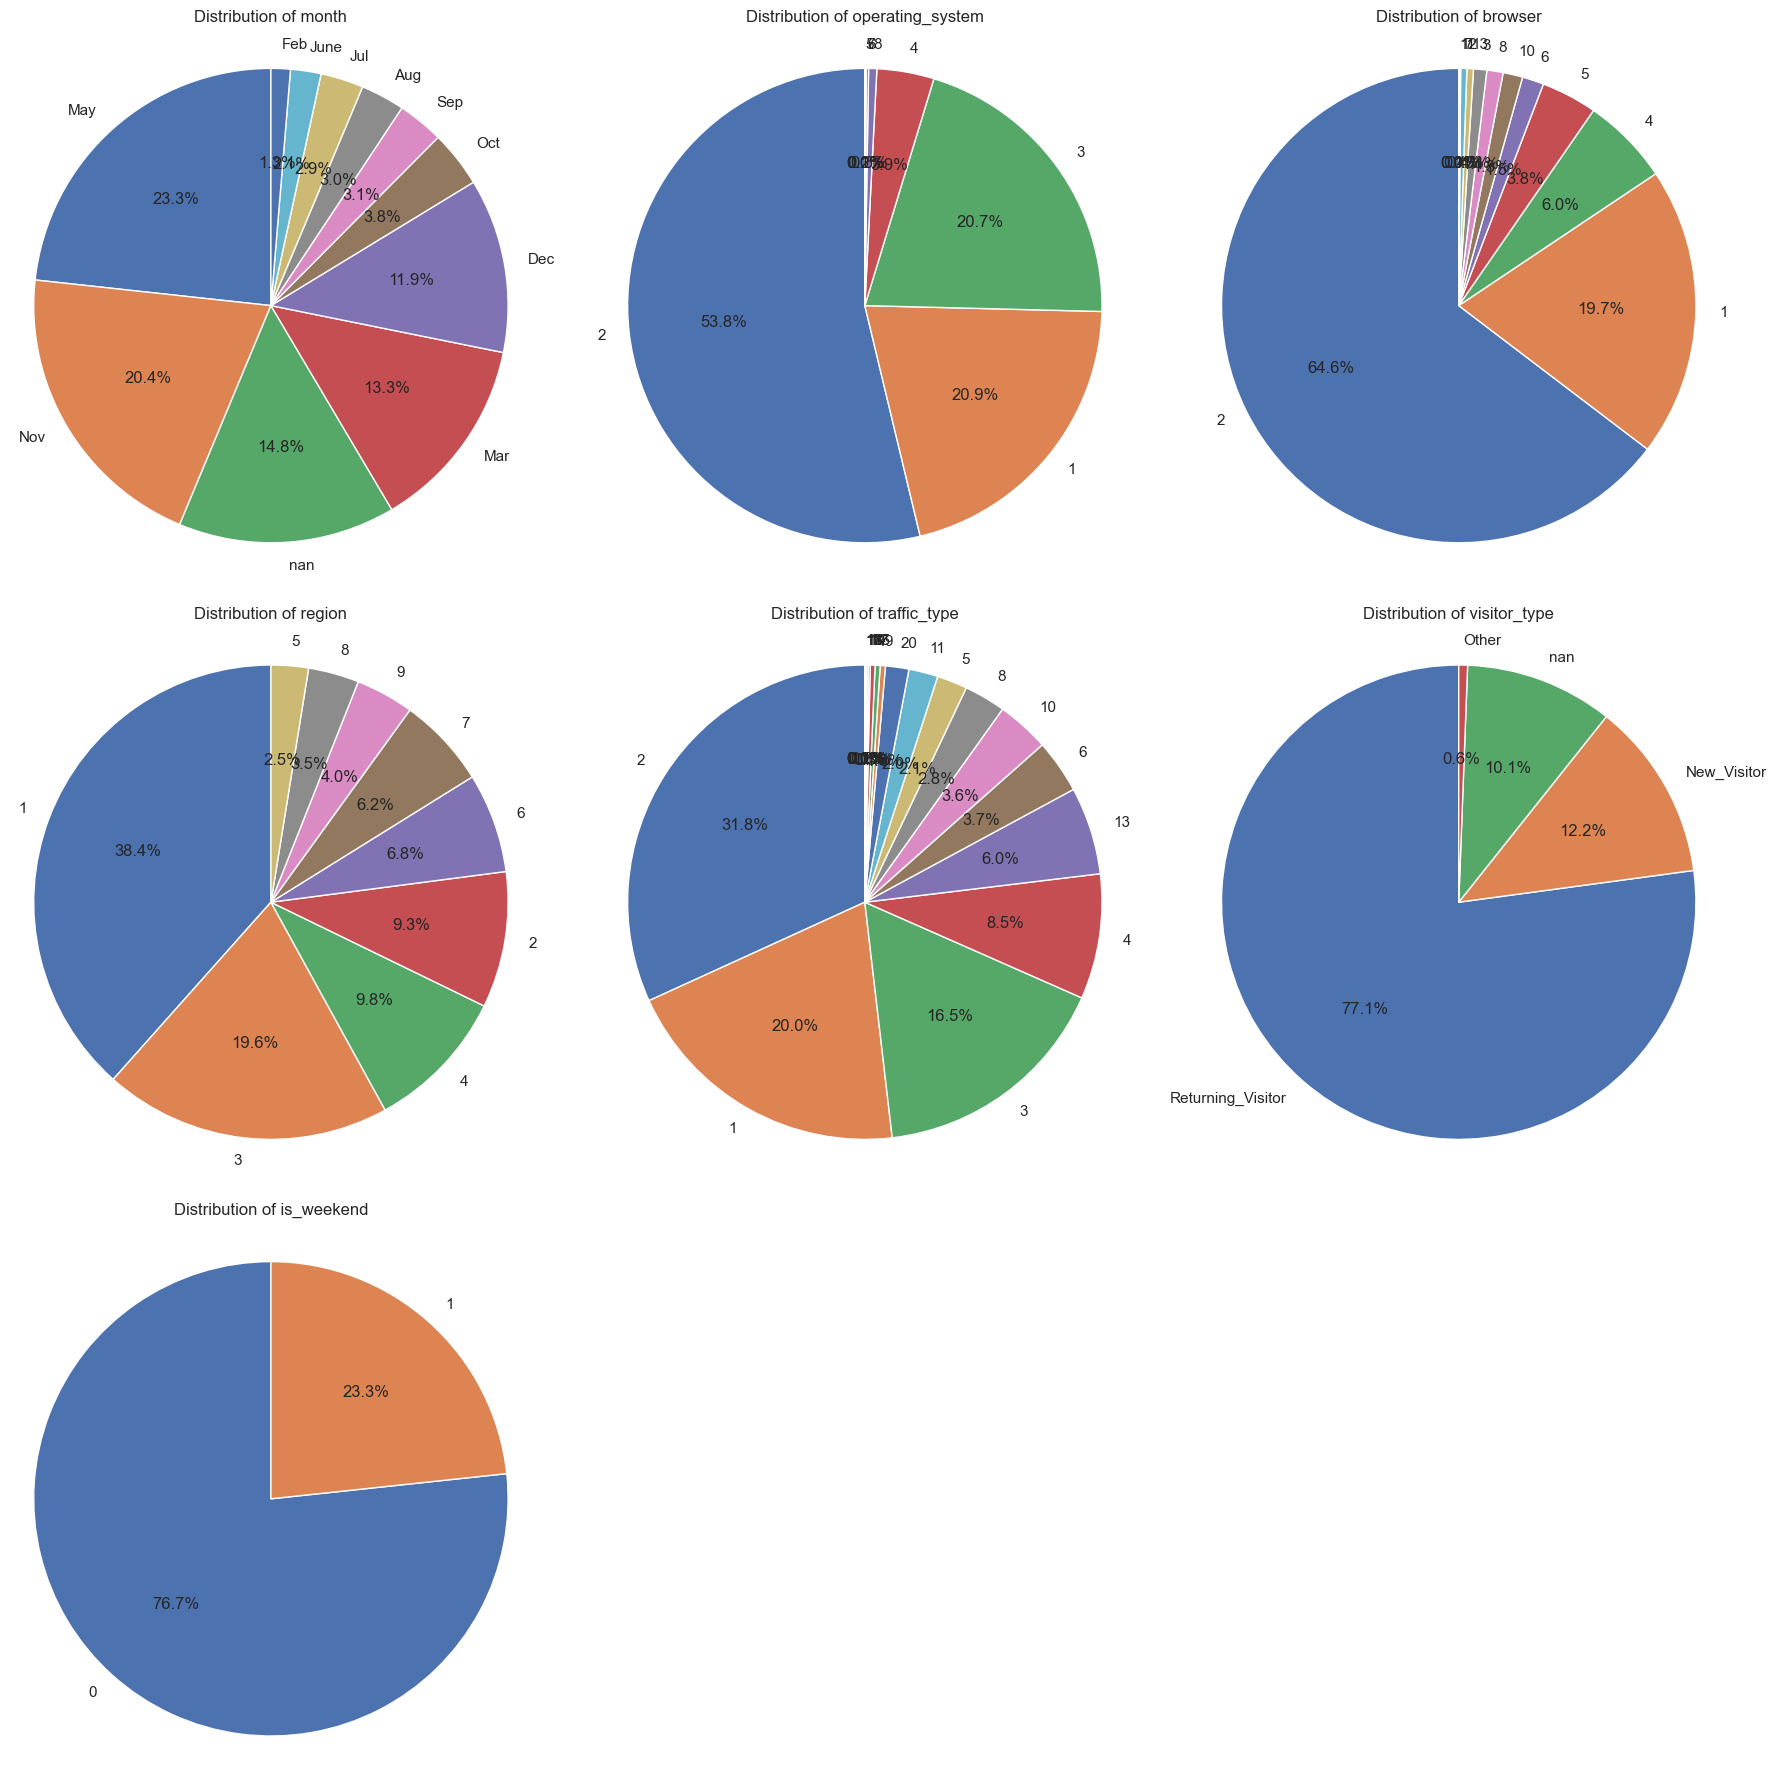

In [8]:
# Pie charts for categorical

pie_features = [
    'month',
    'operating_system',
    'browser',
    'region',
    'traffic_type',
    'visitor_type',
    'is_weekend'
]

# Number of columns in each row
n_cols = 3
# Calculate number of rows needed
n_rows = int(np.ceil(len(pie_features) / n_cols))

# Create subplot grid
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 6 * n_rows)
)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Create each pie chart
for i, feature in enumerate(pie_features):

    counts = df[feature].value_counts(dropna=False)

    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    axes[i].set_title(f'Distribution of {feature}')
    axes[i].axis('equal')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

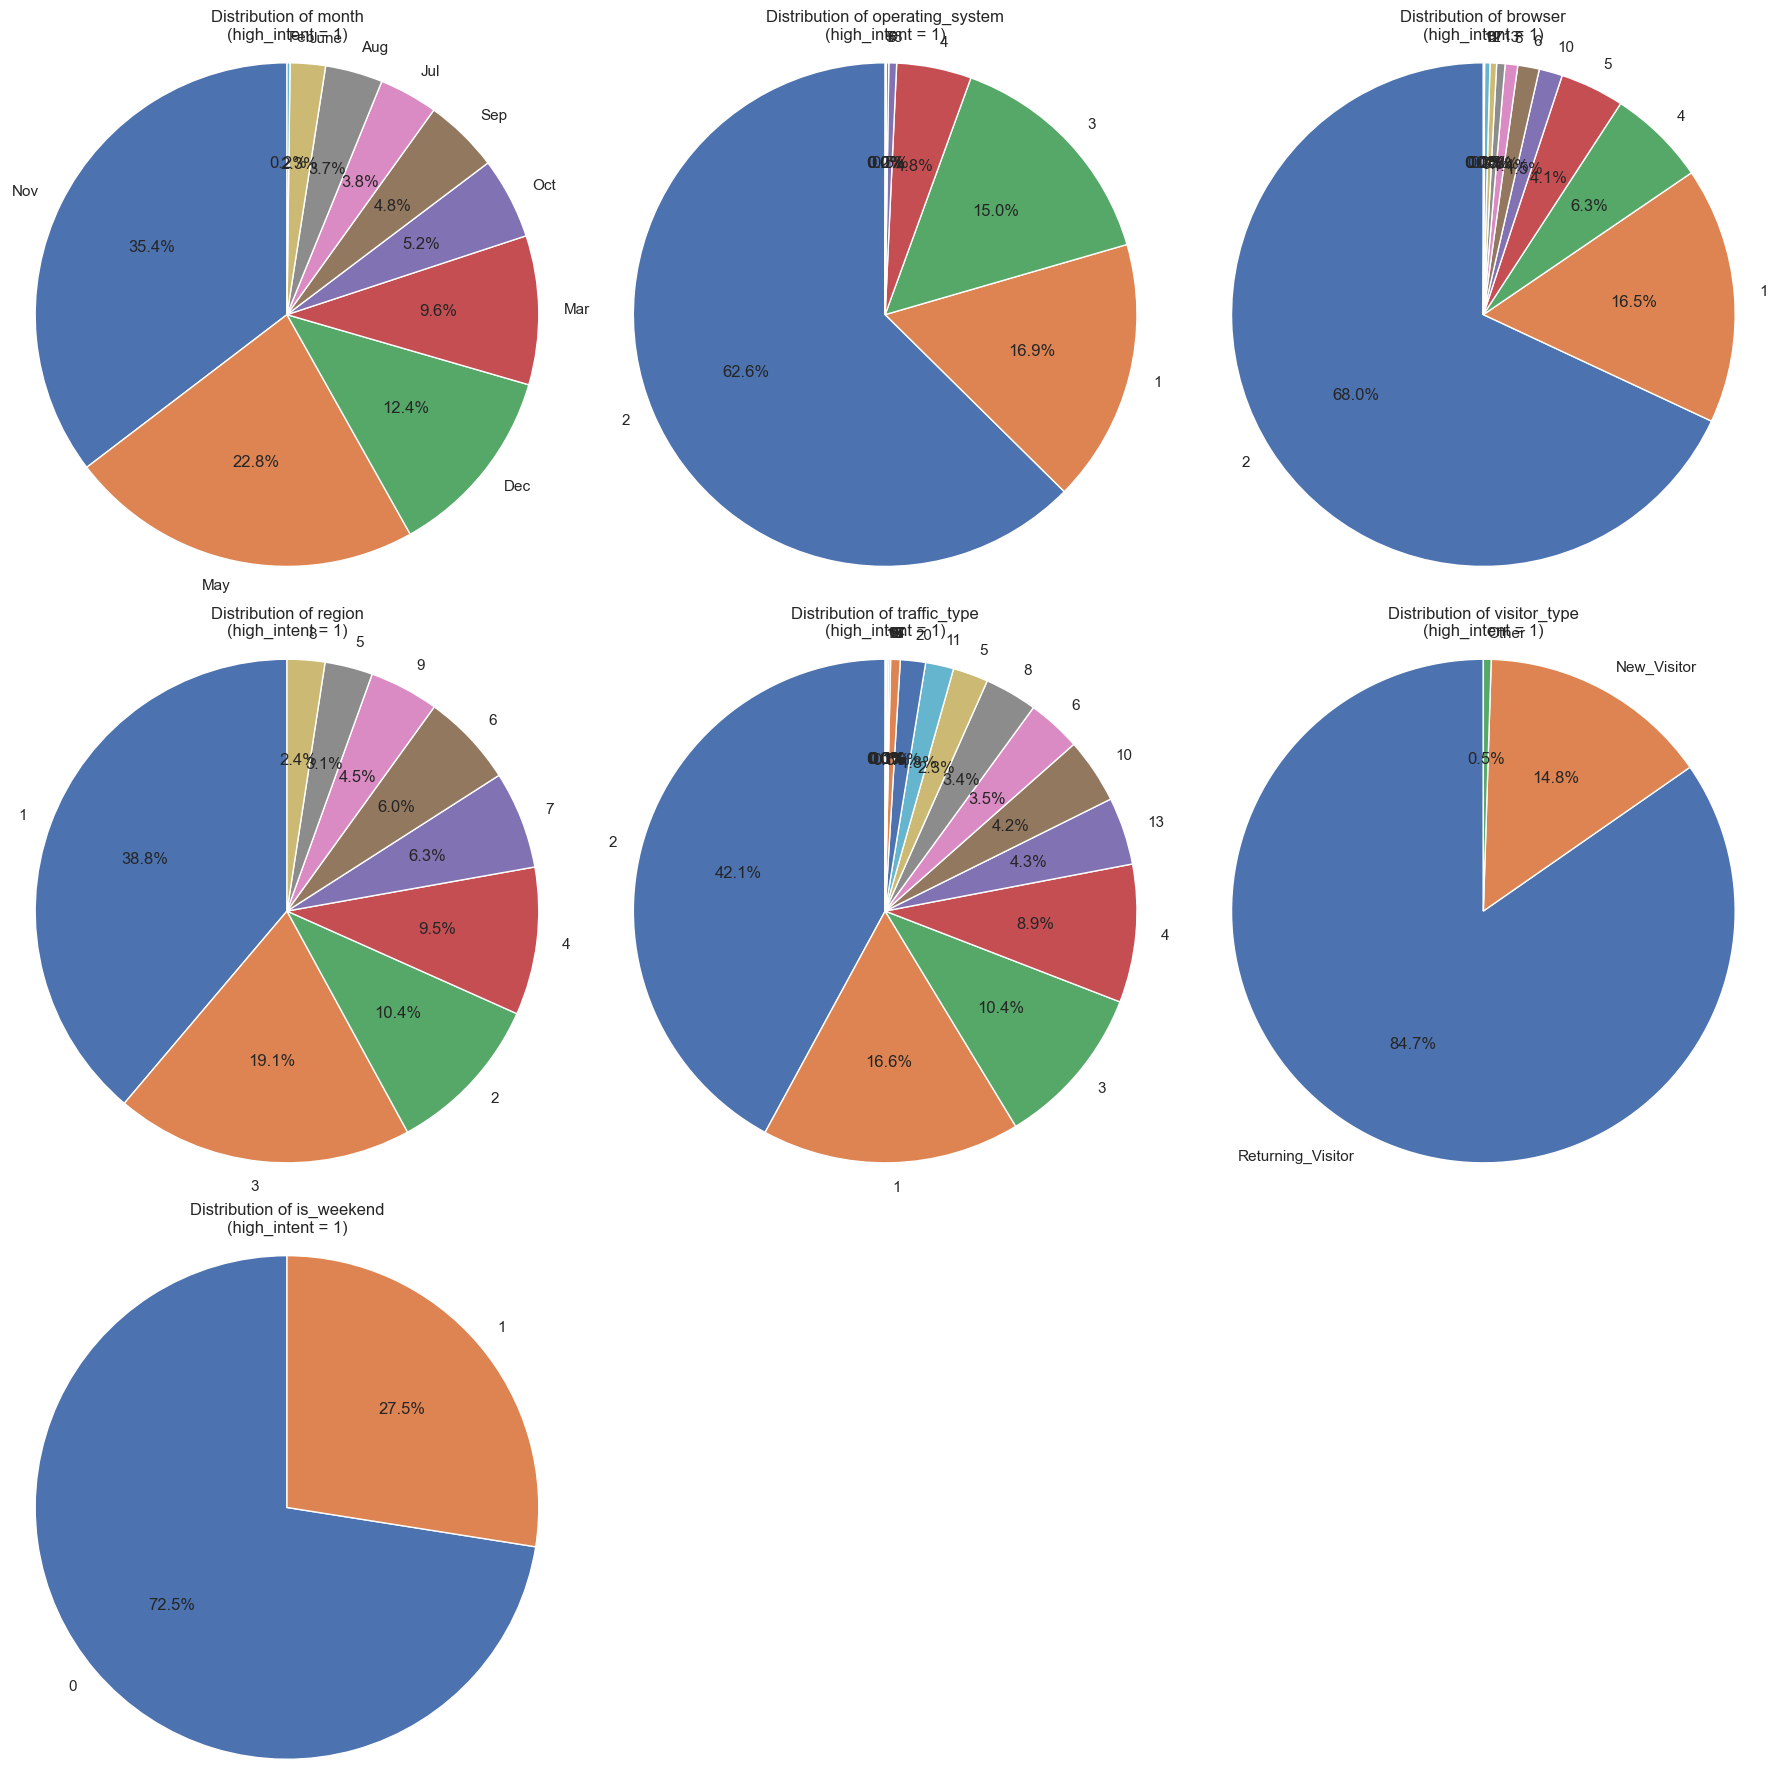

In [ ]:
# Pie charts for categorical features
# ONLY for rows where high_intent == 1

pie_features = [
    'month',
    'operating_system',
    'browser',
    'region',
    'traffic_type',
    'visitor_type',
    'is_weekend'
]

# Filter only high_intent = 1
df_high_intent = df_filled[df_filled['high_intent'] == 1]

# Number of columns in each row
n_cols = 3

# Calculate number of rows needed
n_rows = int(np.ceil(len(pie_features) / n_cols))

# Create subplot grid
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 6 * n_rows)
)

# Flatten axes array
axes = axes.flatten()

# Create pie charts
for i, feature in enumerate(pie_features):

    # Count values only for high_intent == 1
    counts = df_high_intent[feature].value_counts(dropna=False)

    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    axes[i].set_title(
        f'Distribution of {feature}\n(high_intent = 1)'
    )

    axes[i].axis('equal')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

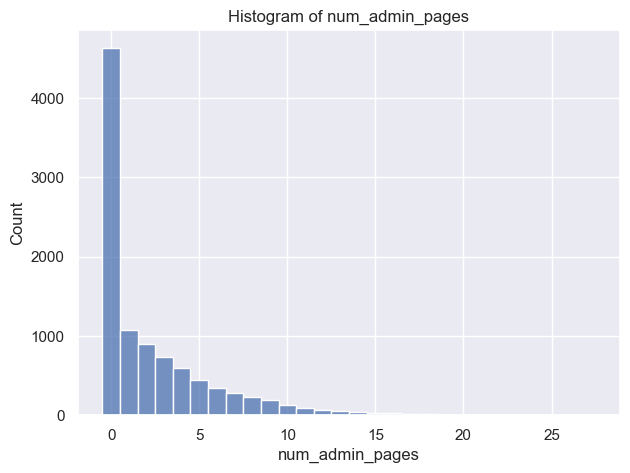

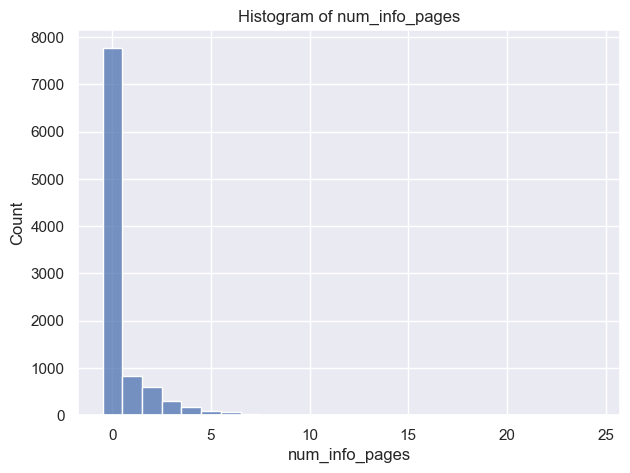

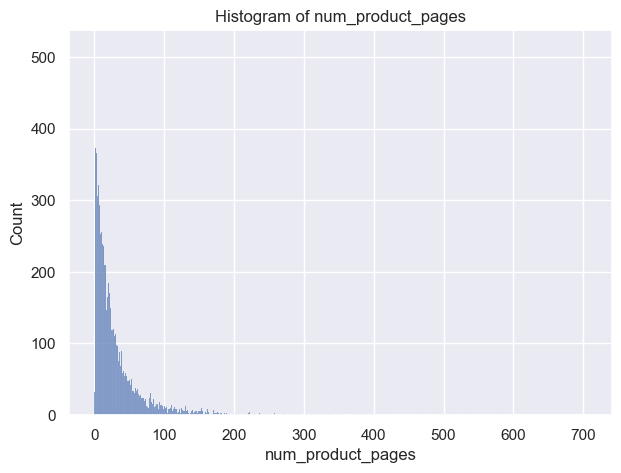

In [11]:
page_features = [
    'num_admin_pages',
    'num_info_pages',
    'num_product_pages'
]

for feature in page_features:

    plt.figure(figsize=(7,5))

    sns.histplot(
        df[feature],
        discrete=True
    )

    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)

    plt.show()

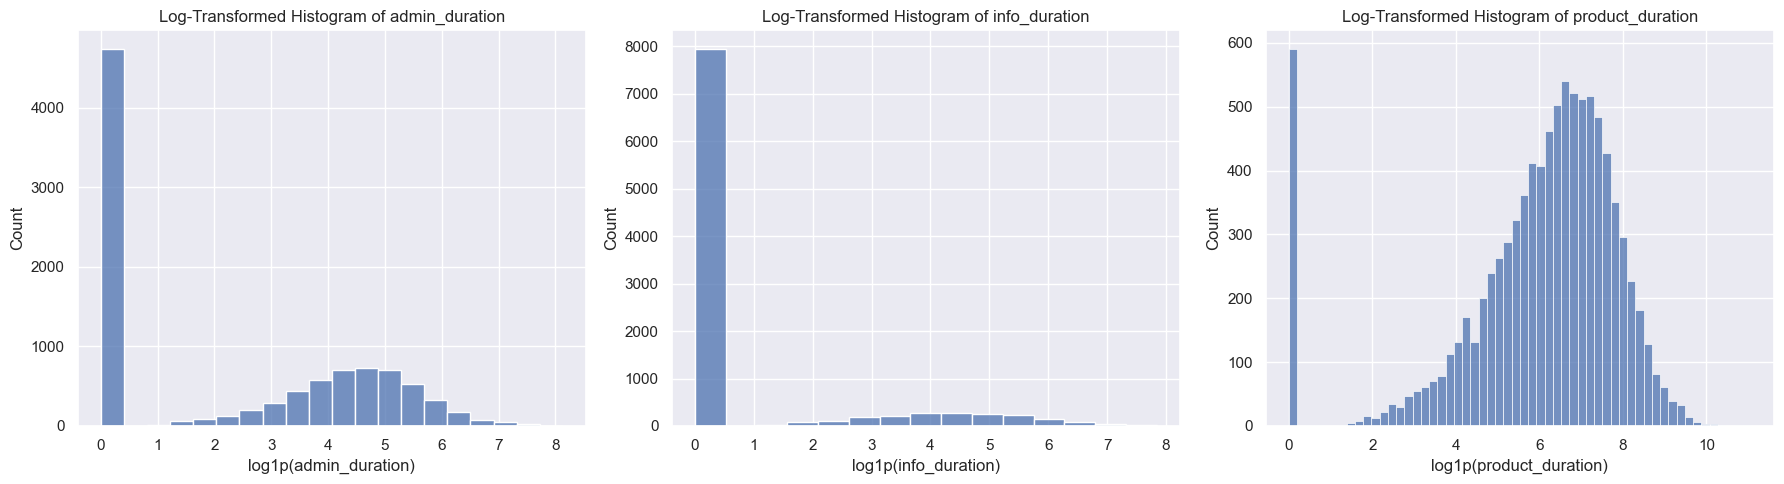

In [ ]:
duration_features = [
    'admin_duration',
    'info_duration',
    'product_duration'
]

# Create subplots in one row
fig, axes = plt.subplots(
    1,
    len(duration_features),
    figsize=(18, 5)
)

# Create each histogram
for i, feature in enumerate(duration_features):

    transformed_feature = np.log1p(df[feature])

    sns.histplot(
        transformed_feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f'Log-Transformed Histogram of {feature}'
    )

    axes[i].set_xlabel(
        f'log1p({feature})'
    )

# Adjust layout
plt.tight_layout()

# Show all plots
plt.show()

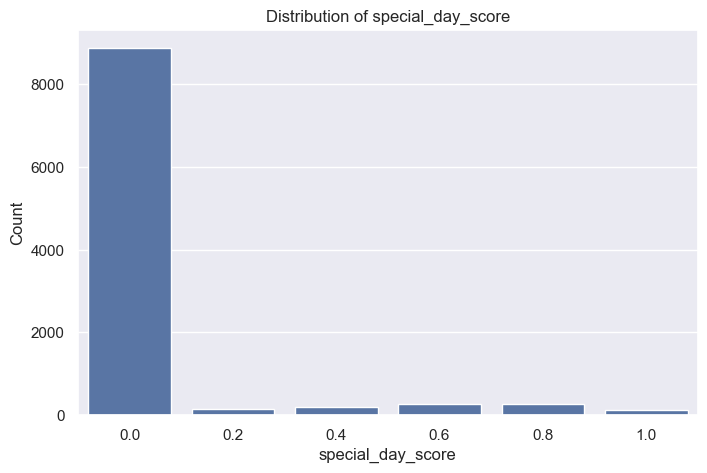

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='special_day_score',
    data=df
)

plt.title('Distribution of special_day_score')
plt.xlabel('special_day_score')
plt.ylabel('Count')

plt.show()

we can see in the plot below the calculated high intent rate for each special_day_score, meaning the proportion of sessions in which high_intent = 1 for every special day level.

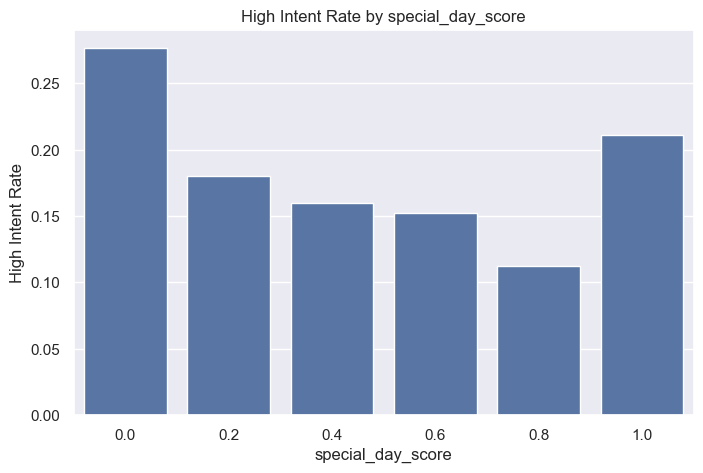

In [ ]:
special_day_conversion = (
    df.groupby('special_day_score')['high_intent']
    .mean()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=special_day_conversion.index,
    y=special_day_conversion.values
)

plt.ylabel('High Intent Rate')
plt.title('High Intent Rate by special_day_score')

plt.show()

In [ ]:
summary = (
    df.groupby('special_day_score')['high_intent']
    .agg(
        samples='count',
        high_intent_count='sum',
        high_intent_rate='mean'
    )
)

summary['high_intent_rate'] *= 100

print(summary)

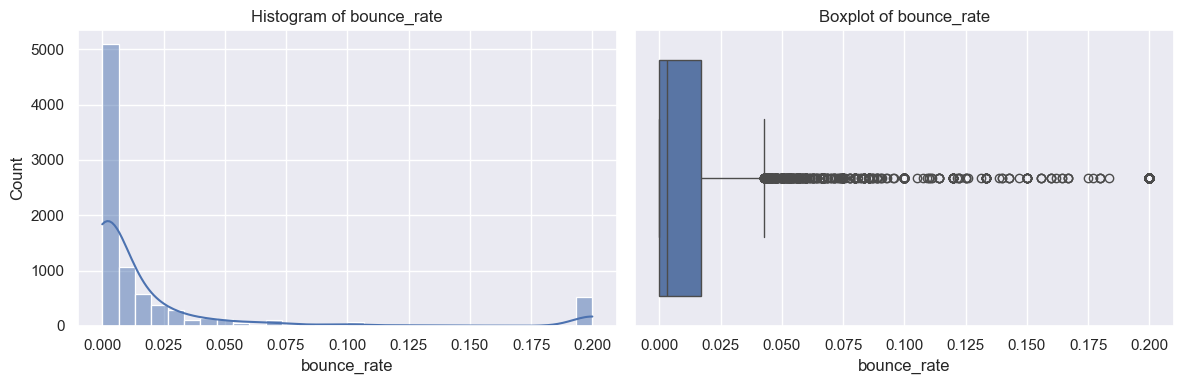

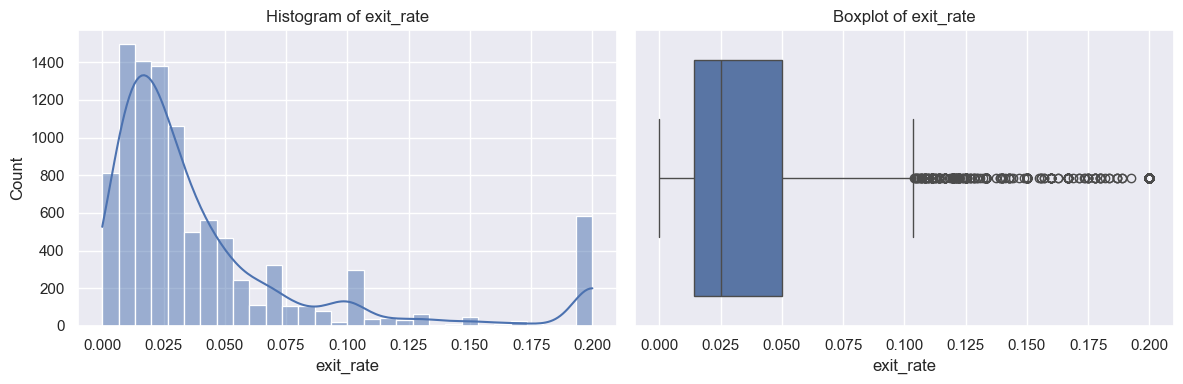

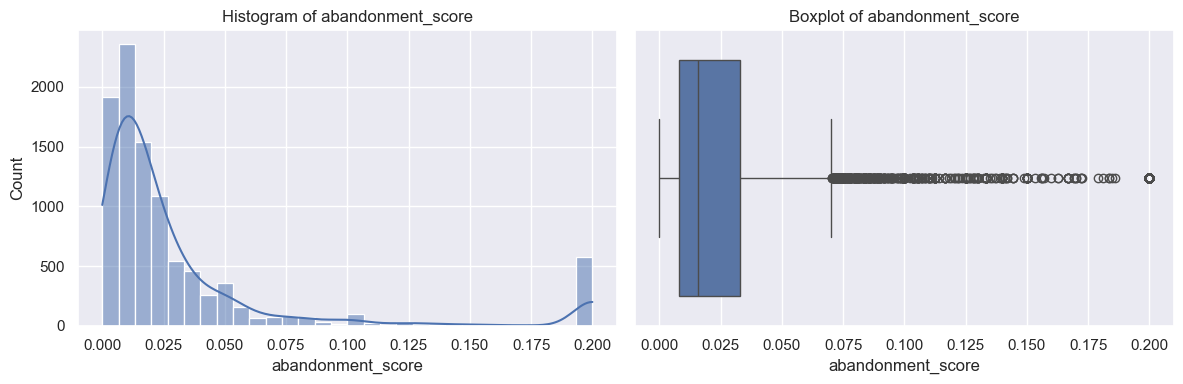

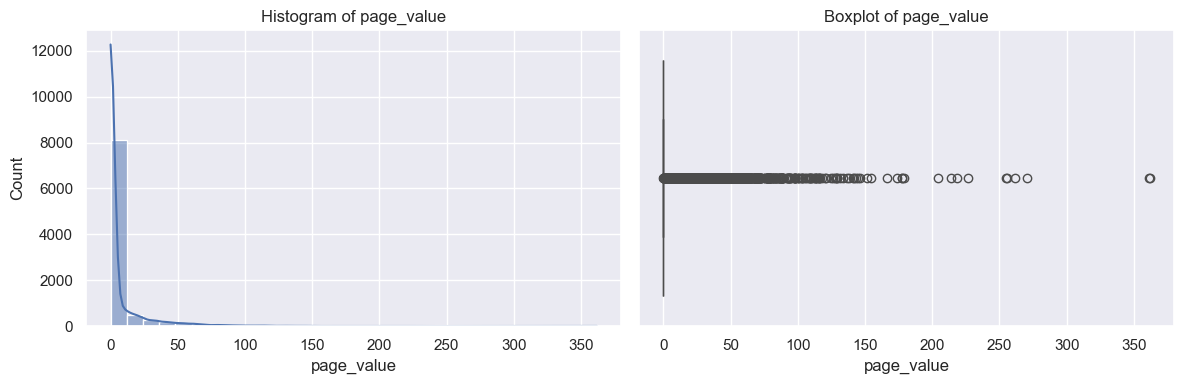

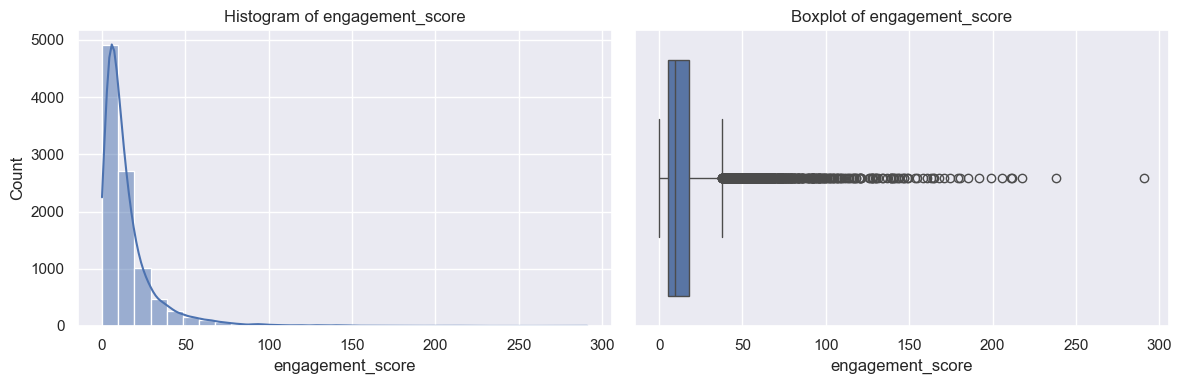

In [ ]:
features_to_plot = [
    'bounce_rate',
    'exit_rate',
    'abandonment_score',
    'page_value',
    'engagement_score'
]

for feature in features_to_plot:

    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(
        df[feature],
        bins=30,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f'Histogram of {feature}')
    axes[0].set_xlabel(feature)

    # Boxplot
    sns.boxplot(
        x=df[feature],
        ax=axes[1]
    )

    axes[1].set_title(f'Boxplot of {feature}')
    axes[1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

In [ ]:
numeric_features = [
    'num_admin_pages',
    'admin_duration',
    'num_info_pages',
    'info_duration',
    'num_product_pages',
    'product_duration',
    'bounce_rate',
    'exit_rate',
    'page_value',
    'engagement_score',
    'abandonment_score'
]

skewness_df = pd.DataFrame({
    'Feature': numeric_features,
    'Skewness': [df[feature].skew() for feature in numeric_features]
})

skewness_df = skewness_df.sort_values(
    by='Skewness',
    ascending=False
)

display(skewness_df)

,Feature,Skewness
5,product_duration,7.755150
3,info_duration,7.599689
8,page_value,6.313180
1,admin_duration,5.743064
4,num_product_pages,4.266238
2,num_info_pages,4.159568
9,engagement_score,4.084522
6,bounce_rate,2.892041
10,abandonment_score,2.632243
7,exit_rate,2.127351


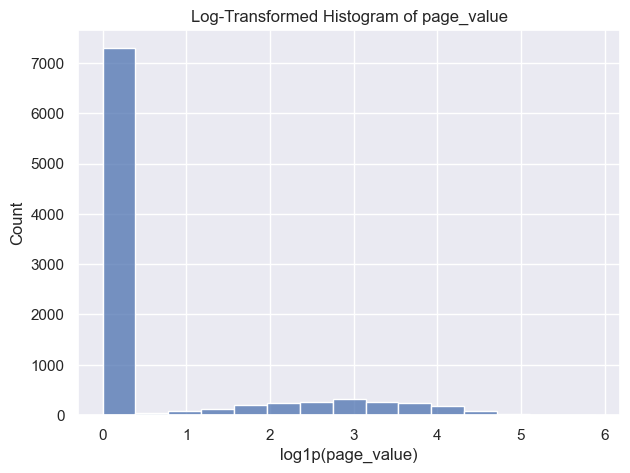

In [ ]:
transformed_feature = np.log1p(df['page_value'])

plt.figure(figsize=(7,5))

sns.histplot(transformed_feature)

plt.title(f'Log-Transformed Histogram of page_value')
plt.xlabel(f'log1p(page_value)')

plt.show()

we need to delete from the table values that are categorial

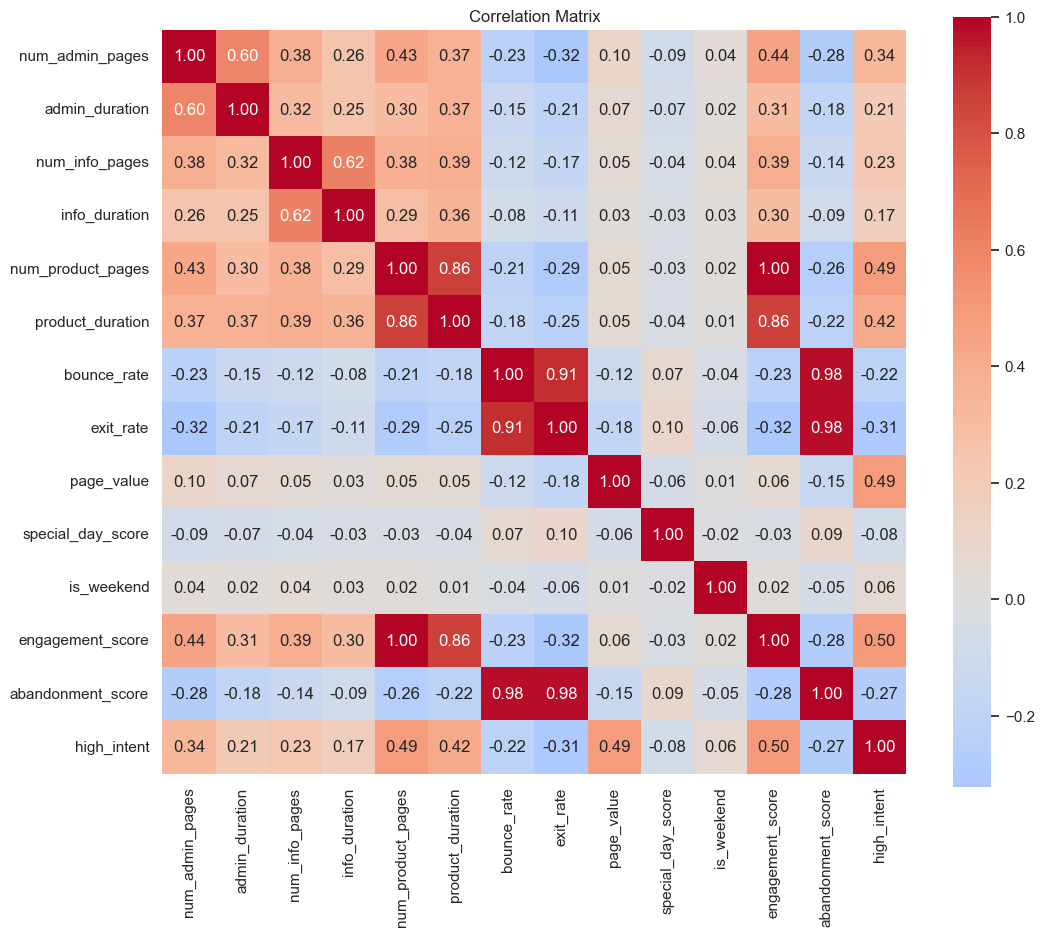

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

columns_to_remove = [
    'month',
    'operating_system',
    'browser',
    'region',
    'traffic_type',
    'visitor_type'
]

numeric_df = df.drop(columns=columns_to_remove)

# Compute correlation matrix
corr_matrix = numeric_df.corr()


plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='bounce_rate', ylabel='abandonment_score'>

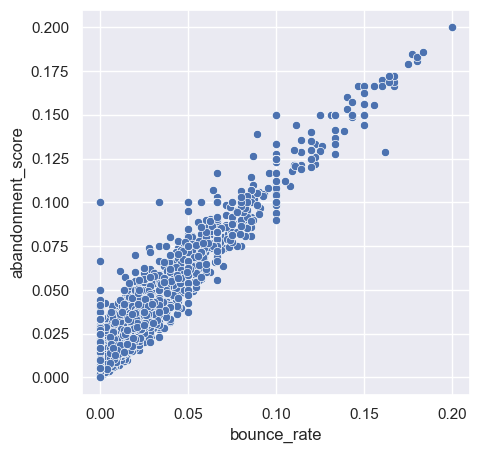

In [ ]:
sns.scatterplot(
    x='bounce_rate',
    y='abandonment_score',
    data=df
)

<Axes: xlabel='exit_rate', ylabel='abandonment_score'>

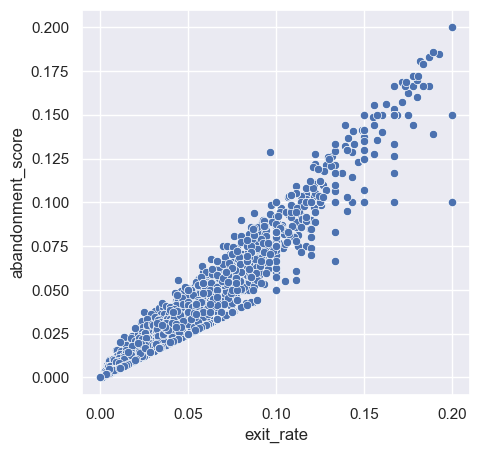

In [ ]:
sns.scatterplot(
    x='exit_rate',
    y='abandonment_score',
    data=df
)

<Axes: xlabel='num_product_pages', ylabel='engagement_score'>

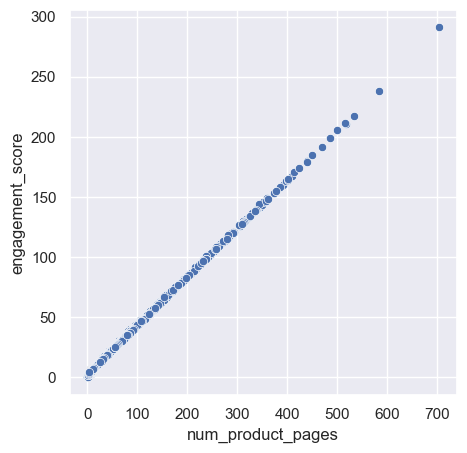

In [ ]:
sns.scatterplot(
    x='num_product_pages',
    y='engagement_score',
    data=df
)

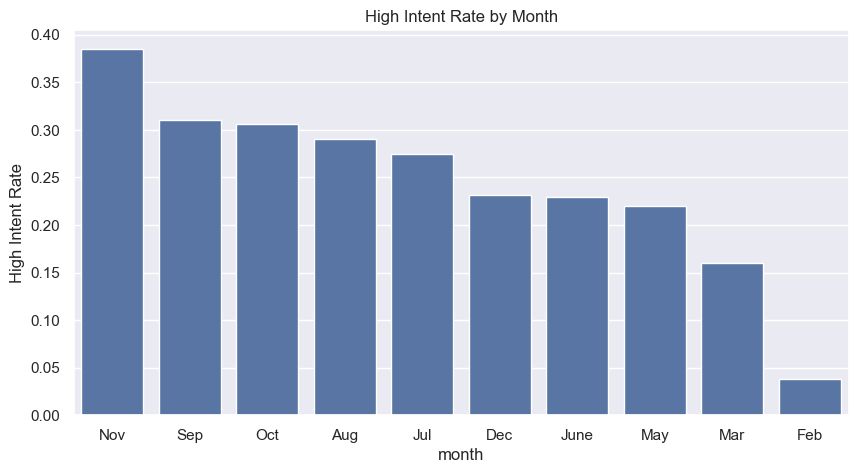

In [ ]:
month_conversion = (
    df.groupby('month')['high_intent']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=month_conversion.index,
    y=month_conversion.values
)

plt.ylabel('High Intent Rate')
plt.title('High Intent Rate by Month')

plt.show()

optional:
see if there is corr between weekend & high intent 

high_intent        0        1
is_weekend                   
0            0.75043  0.24957
1            0.68856  0.31144


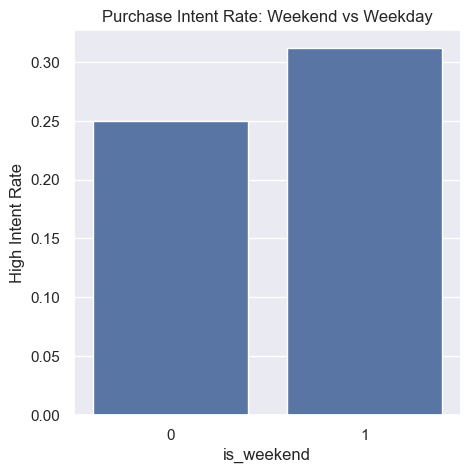

p-value: 4.446156357306825e-09


In [ ]:
weekend_table = pd.crosstab(
    df['is_weekend'],
    df['high_intent'],
    normalize='index'
)

print(weekend_table)

weekend_conversion = (
    df.groupby('is_weekend')['high_intent']
    .mean()
)

sns.barplot(
    x=weekend_conversion.index,
    y=weekend_conversion.values
)

plt.ylabel('High Intent Rate')
plt.title('Purchase Intent Rate: Weekend vs Weekday')

plt.show()

from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['is_weekend'],
    df['high_intent']
)

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

We saw that `product_duration` has many missing values.
It can be derived directly from context: when `num_product_pages == 0`,
the visitor browsed no product pages, so `product_duration` must also be zero.

The code below creates `df_filled` as a working copy of the training set
and applies this deterministic zero-fill as the first imputation step.
All subsequent statistical imputation steps operate on `df_filled`.

In [ ]:
# fill with 0 cells which the corresponding is 0
# Create a copy of the original dataframe
df_filled = df.copy()

# Define condition:
# rows where num_product_pages == 0
# and product_duration is missing
condition = (
    (df_filled['num_product_pages'] == 0) &
    (df_filled['product_duration'].isnull())
)

# Count how many values will be filled
num_filled = condition.sum()

# Fill the missing values with 0
df_filled.loc[condition, 'product_duration'] = 0

# Print summary
print(f"Number of missing values filled in 'product_duration': {num_filled}")

print("Remaining missing values in 'product_duration':",
      df_filled['product_duration'].isnull().sum())

print("Original missing values:",
      df['product_duration'].isnull().sum())

print("Missing values after filling:",
      df_filled['product_duration'].isnull().sum())

Number of missing values filled in 'product_duration': 3
Remaining missing values in 'product_duration': 395
Original missing values: 398
Missing values after filling: 395


## Section 7 — Missing Value Imputation

Methods selected from a private benchmark (`private_imputation_method_benchmark.py`)
that evaluated each candidate against ground-truth values from the original dataset:

| Feature | Method | Notes |
|---|---|---|
| `month` | RandomForestClassifier | Best benchmark accuracy; no label leakage |
| `visitor_type` | RandomForestClassifier | Best accuracy; faster than KNN (no k-tuning) |
| `product_duration` | LinearRegression | Strong performance; simpler and more interpretable than RF |
| `page_value` | Conditional Median (by `traffic_type`) | Lowest MAE; robust to outliers |

**Key constraint**: `high_intent` (the classification target) is **never** used
as a predictor in any imputation step — doing so would constitute label leakage.

In [ ]:
# =====================================================
# Pipeline Parameters
# =====================================================
# Central dictionary for all imputation hyperparameters.
# Shared between training-data imputation and preprocess_test().

pipeline_params = {
    'random_seed'         : 42,
    'rf_n_estimators'     : 200,
    'rf_max_depth'        : 10,
    'rf_min_samples_leaf' : 3,
    'engagement_clip_pct' : 0.95,
    'page_value_group_col': 'traffic_type',
}

RANDOM_SEED = pipeline_params['random_seed']
np.random.seed(RANDOM_SEED)

# =====================================================
# RandomForest imputation for month
# =====================================================
# Benchmark result: RandomForestClassifier ranked #1
# over GlobalMode, ConditionalMode, and KNN.
# high_intent is NOT used — no label leakage.

from sklearn.ensemble import RandomForestClassifier

RF_MONTH_FEATURES = [
    'num_product_pages', 'exit_rate', 'admin_duration', 'info_duration',
    'special_day_score', 'is_weekend', 'operating_system', 'browser',
    'region', 'traffic_type', 'engagement_score', 'abandonment_score',
]

# Record distribution before imputation (used in next cell for comparison)
month_before_dist = (
    df_filled[df_filled['month'].notna()]['month']
    .value_counts(normalize=True)
)

# Split into known and missing
month_known   = df_filled[df_filled['month'].notna()].dropna(subset=RF_MONTH_FEATURES)
month_missing = df_filled[df_filled['month'].isna()].dropna(subset=RF_MONTH_FEATURES)

print(f"month — known: {len(month_known)}, "
      f"missing in train: {df_filled['month'].isna().sum()}")

# Fit RandomForest on known rows (shopper_train.csv only)
rf_month_imputer = RandomForestClassifier(
    n_estimators    =pipeline_params['rf_n_estimators'],
    max_depth       =pipeline_params['rf_max_depth'],
    min_samples_leaf=pipeline_params['rf_min_samples_leaf'],
    random_state    =RANDOM_SEED,
    n_jobs          =-1,
)
rf_month_imputer.fit(
    month_known[RF_MONTH_FEATURES],
    month_known['month'],
)

# Predict and fill
if len(month_missing) > 0:
    df_filled.loc[month_missing.index, 'month'] = rf_month_imputer.predict(
        month_missing[RF_MONTH_FEATURES]
    )

# Fallback: rows where RF features are also missing → global mode
month_mode = df_filled.loc[df_filled['month'].notna(), 'month'].mode()[0]
remaining_month = df_filled['month'].isna().sum()
if remaining_month > 0:
    df_filled['month'] = df_filled['month'].fillna(month_mode)
    print(f"Fallback mode fill applied to {remaining_month} row(s).")

print(f"Remaining missing month values: {df_filled['month'].isna().sum()}")

In [ ]:
# =====================================================
# Month distribution: BEFORE vs AFTER imputation
# =====================================================

month_after_dist = (
    df_filled['month'].value_counts(normalize=True)
)

all_months = sorted(
    set(month_before_dist.index) | set(month_after_dist.index)
)

month_before_dist = month_before_dist.reindex(all_months, fill_value=0)
month_after_dist  = month_after_dist.reindex(all_months, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].pie(
    month_before_dist,
    labels=month_before_dist.index,
    autopct='%1.1f%%',
    startangle=90,
)
axes[0].set_title('Month Distribution BEFORE Imputation\n(observed rows only)')
axes[0].axis('equal')

axes[1].pie(
    month_after_dist,
    labels=month_after_dist.index,
    autopct='%1.1f%%',
    startangle=90,
)
axes[1].set_title('Month Distribution AFTER Imputation\n(all rows)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# RandomForest imputation for visitor_type
# =====================================================
# Benchmark result: RandomForestClassifier ranked #1
# over GlobalMode, ConditionalMode, and KNN.
# Replaces the previous KNN approach.
# high_intent is NOT used — no label leakage.

RF_VT_FEATURES = [
    'num_product_pages', 'exit_rate', 'admin_duration', 'info_duration',
    'special_day_score', 'is_weekend', 'operating_system', 'browser',
    'region', 'traffic_type', 'engagement_score', 'abandonment_score',
]

# Distribution before imputation
vt_before_dist = (
    df_filled[df_filled['visitor_type'].notna()]['visitor_type']
    .value_counts(normalize=True)
)

# Split into known and missing
vt_known   = df_filled[df_filled['visitor_type'].notna()].dropna(subset=RF_VT_FEATURES)
vt_missing = df_filled[df_filled['visitor_type'].isna()].dropna(subset=RF_VT_FEATURES)

print(f"visitor_type — known: {len(vt_known)}, "
      f"missing in train: {df_filled['visitor_type'].isna().sum()}")

# Fit RandomForest on known rows (shopper_train.csv only)
rf_vt_imputer = RandomForestClassifier(
    n_estimators    =pipeline_params['rf_n_estimators'],
    max_depth       =pipeline_params['rf_max_depth'],
    min_samples_leaf=pipeline_params['rf_min_samples_leaf'],
    random_state    =RANDOM_SEED,
    n_jobs          =-1,
)
rf_vt_imputer.fit(
    vt_known[RF_VT_FEATURES],
    vt_known['visitor_type'],
)

# Predict and fill
if len(vt_missing) > 0:
    df_filled.loc[vt_missing.index, 'visitor_type'] = rf_vt_imputer.predict(
        vt_missing[RF_VT_FEATURES]
    )

# Fallback: rows where RF features are also missing → global mode
vt_mode = df_filled.loc[df_filled['visitor_type'].notna(), 'visitor_type'].mode()[0]
remaining_vt = df_filled['visitor_type'].isna().sum()
if remaining_vt > 0:
    df_filled['visitor_type'] = df_filled['visitor_type'].fillna(vt_mode)
    print(f"Fallback mode fill applied to {remaining_vt} row(s).")

print(f"Remaining missing visitor_type values: {df_filled['visitor_type'].isna().sum()}")

# Distribution after imputation
vt_after_dist = (
    df_filled['visitor_type'].value_counts(normalize=True)
)

all_vt_cats = sorted(set(vt_before_dist.index) | set(vt_after_dist.index))
vt_before_dist = vt_before_dist.reindex(all_vt_cats, fill_value=0)
vt_after_dist  = vt_after_dist.reindex(all_vt_cats, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].pie(
    vt_before_dist,
    labels=vt_before_dist.index,
    autopct='%1.1f%%',
    startangle=90,
)
axes[0].set_title('Visitor Type BEFORE Imputation\n(observed rows only)')
axes[0].axis('equal')

axes[1].pie(
    vt_after_dist,
    labels=vt_after_dist.index,
    autopct='%1.1f%%',
    startangle=90,
)
axes[1].set_title('Visitor Type AFTER Imputation\n(all rows)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
# Remove columns from df_filled
# we can remove because of strong correlation

df_filled = df_filled.drop(
    columns=[
        'bounce_rate',
        'num_product_pages'
    ],
    errors='ignore'
)

# Verify removal
print(df_filled.columns)

Index(['num_admin_pages', 'admin_duration', 'num_info_pages', 'info_duration',
       'product_duration', 'exit_rate', 'page_value', 'special_day_score',
       'month', 'operating_system', 'browser', 'region', 'traffic_type',
       'visitor_type', 'is_weekend', 'engagement_score', 'abandonment_score',
       'high_intent'],
      dtype='object')


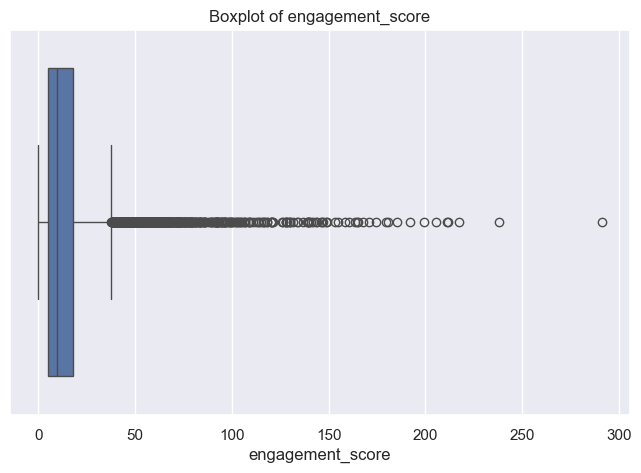

count    9864.000000
mean       15.268306
std        18.652267
min         0.000000
50%         9.751604
90%        33.402137
95%        48.114138
99%        93.051457
max       291.069181
Name: engagement_score, dtype: float64
48.11413816584409


In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_filled['engagement_score']
)

plt.title('Boxplot of engagement_score')

plt.show()

print(
    df_filled['engagement_score']
    .describe(percentiles=[0.90, 0.95, 0.99])
)

upper_limit = (
    df_filled['engagement_score']
    .quantile(0.95)
)

print(upper_limit)

df_filled['engagement_score_clipped'] = np.clip(
    df_filled['engagement_score'],
    a_min=None,
    a_max=upper_limit
)



In [ ]:
# =====================================
# LinearRegression imputation
# for product_duration
# using engagement_score_clipped
# =====================================
# Benchmark: LinearRegression ranked among the
# top methods for product_duration. Chosen over
# RandomForest for interpretability and simplicity.
# high_intent is NOT used — no label leakage.

from sklearn.linear_model import LinearRegression

# =====================================
# Split data
# =====================================

# Rows with known product_duration
train_df = df_filled[
    df_filled['product_duration'].notna()
].copy()

# Rows with missing product_duration
predict_df = df_filled[
    df_filled['product_duration'].isna()
].copy()

print(f"product_duration — known: {len(train_df)}, missing: {len(predict_df)}")

# =====================================
# Features and target
# =====================================

X_train   = train_df[['engagement_score_clipped']]
y_train   = train_df['product_duration']
X_predict = predict_df[['engagement_score_clipped']]

# =====================================
# Train model (shopper_train.csv only)
# =====================================

lr_product_imputer = LinearRegression()
lr_product_imputer.fit(X_train, y_train)

# =====================================
# Predict missing values
# =====================================

predicted_values = lr_product_imputer.predict(X_predict)

# Prevent negative predictions
predicted_values = np.clip(predicted_values, a_min=0, a_max=None)

# =====================================
# Fill missing values
# =====================================

df_filled.loc[
    df_filled['product_duration'].isna(),
    'product_duration'
] = predicted_values

# =====================================
# Final check
# =====================================

print(
    "Remaining missing values:",
    df_filled['product_duration'].isna().sum()
)

print("\nFilled Values Statistics:")
print(pd.Series(predicted_values).describe())

print("\nCorrelation after imputation:")
print(
    df_filled[
        ['product_duration', 'engagement_score_clipped']
    ].corr()
)

In [ ]:
print("Original correlation (before imputation):")
print(
    df[
        ['product_duration', 'engagement_score']
    ].corr()
)

print("\nCorrelation after imputation (engagement_score_clipped):")
print(
    df_filled[
        ['product_duration', 'engagement_score_clipped']
    ].corr()
)

In [ ]:
# =====================================================
# Conditional Median imputation for page_value
# =====================================================
# Benchmark: ConditionalMedian by traffic_type
# achieved the lowest MAE among all tested methods
# (Median, Ridge, RandomForest, KNN).
# Different traffic sources have distinct
# page-value distributions, making traffic_type
# an effective grouping variable.
# high_intent is NOT used — no label leakage.

group_col = pipeline_params['page_value_group_col']  # 'traffic_type'

# =====================================
# Compute conditional medians
# from observed rows (train only)
# =====================================

page_value_medians = (
    df_filled[df_filled['page_value'].notna()]
    .groupby(group_col)['page_value']
    .median()
)

page_value_global_median = df_filled['page_value'].median()

print(f"Conditional medians by {group_col}:")
print(page_value_medians.to_string())
print(f"\nGlobal fallback median: {page_value_global_median:.4f}")

# =====================================
# Apply to missing rows
# =====================================

missing_pv_mask = df_filled['page_value'].isna()
n_missing_pv    = missing_pv_mask.sum()
print(f"\nMissing page_value values: {n_missing_pv}")

df_filled.loc[missing_pv_mask, 'page_value'] = (
    df_filled.loc[missing_pv_mask, group_col]
    .map(page_value_medians)
    .fillna(page_value_global_median)
    .values
)

# =====================================
# Final check
# =====================================

print(f"Remaining missing page_value: {df_filled['page_value'].isna().sum()}")

print("\nFilled Values Statistics:")
print(df_filled.loc[missing_pv_mask, 'page_value'].describe())

# =====================================
# Distribution: known vs imputed
# =====================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df_filled[~missing_pv_mask]['page_value'],
    bins=50, color='steelblue', alpha=0.7, label='Known',
)
axes[0].hist(
    df_filled[missing_pv_mask]['page_value'],
    bins=50, color='salmon', alpha=0.7, label='Imputed',
)
axes[0].set_title('page_value: Known vs Imputed (raw scale)')
axes[0].set_xlabel('page_value')
axes[0].legend()

axes[1].hist(
    np.log1p(df_filled[~missing_pv_mask]['page_value']),
    bins=50, color='steelblue', alpha=0.7, label='Known',
)
axes[1].hist(
    np.log1p(df_filled[missing_pv_mask]['page_value']),
    bins=50, color='salmon', alpha=0.7, label='Imputed',
)
axes[1].set_title('page_value: Known vs Imputed (log scale)')
axes[1].set_xlabel('log(1 + page_value)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Create a summary DataFrame with metadata for each column
data_summary = pd.DataFrame({
    'Data Type': df_filled.dtypes,  # Data type of each column
    'Missing Values': df_filled.isnull().sum(),  # Number of missing values in each column
    'Missing %': df_filled.isnull().mean() * 100,  # Percentage of missing values in each column
    'Unique Values': df_filled.nunique()  # Number of unique values in each column
})

display(data_summary)  # Display the data summary DataFrame

,Data Type,Missing Values,Missing %,Unique Values
num_admin_pages,int64,0,0.0,26
admin_duration,float64,0,0.0,2805
num_info_pages,int64,0,0.0,16
info_duration,float64,0,0.0,1064
product_duration,float64,0,0.0,7840
exit_rate,float64,0,0.0,3974
page_value,float64,0,0.0,2527
special_day_score,float64,0,0.0,6
month,object,0,0.0,10
operating_system,int64,0,0.0,8


In [ ]:
import os

print(os.getcwd())

# Save df_filled as CSV file
df_filled.to_csv(
    "df_filled.csv",
    index=False
)

print("df_filled.csv was saved successfully.")

g:\My Drive\DM&DV\project
df_filled.csv was saved successfully.


In [ ]:
# =====================================================
# preprocess_test: Apply trained imputers to test set
# =====================================================
# All imputers were fit on shopper_train.csv only.
# high_intent is NOT available in the test set
# and is NOT used in any step.

def preprocess_test(df_raw):
    """
    Apply the training preprocessing pipeline to a raw test DataFrame.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Raw data loaded from shopper_test.csv.

    Returns
    -------
    pd.DataFrame
        Preprocessed DataFrame with no missing values in
        month, visitor_type, product_duration, page_value.
    """
    df = df_raw.copy()

    # Step 1: Deterministic zero-fill for product_duration
    cond = (df['num_product_pages'] == 0) & df['product_duration'].isna()
    df.loc[cond, 'product_duration'] = 0.0

    # Step 2: Impute month with rf_month_imputer
    month_miss = df['month'].isna()
    if month_miss.sum() > 0:
        can_pred = df[month_miss].dropna(subset=RF_MONTH_FEATURES)
        if len(can_pred) > 0:
            df.loc[can_pred.index, 'month'] = rf_month_imputer.predict(
                can_pred[RF_MONTH_FEATURES]
            )
        df['month'] = df['month'].fillna(month_mode)

    # Step 3: Impute visitor_type with rf_vt_imputer
    vt_miss = df['visitor_type'].isna()
    if vt_miss.sum() > 0:
        can_pred = df[vt_miss].dropna(subset=RF_VT_FEATURES)
        if len(can_pred) > 0:
            df.loc[can_pred.index, 'visitor_type'] = rf_vt_imputer.predict(
                can_pred[RF_VT_FEATURES]
            )
        df['visitor_type'] = df['visitor_type'].fillna(vt_mode)

    # Step 4: Drop bounce_rate and num_product_pages
    df = df.drop(columns=['bounce_rate', 'num_product_pages'], errors='ignore')

    # Step 5: engagement_score_clipped — use training 95th-percentile threshold
    df['engagement_score_clipped'] = np.clip(
        df['engagement_score'],
        a_min=None,
        a_max=upper_limit,
    )

    # Step 6: Impute product_duration with lr_product_imputer
    pd_miss = df['product_duration'].isna()
    if pd_miss.sum() > 0:
        df.loc[pd_miss, 'product_duration'] = np.clip(
            lr_product_imputer.predict(df.loc[pd_miss, ['engagement_score_clipped']]),
            a_min=0, a_max=None,
        )

    # Step 7: Impute page_value with conditional medians by traffic_type
    pv_miss = df['page_value'].isna()
    if pv_miss.sum() > 0:
        df.loc[pv_miss, 'page_value'] = (
            df.loc[pv_miss, pipeline_params['page_value_group_col']]
            .map(page_value_medians)
            .fillna(page_value_global_median)
            .values
        )

    return df


# =====================================================
# Apply to shopper_test.csv
# =====================================================

df_test_raw  = pd.read_csv('shopper_test.csv')
df_test_proc = preprocess_test(df_test_raw)

print('Test set preprocessing complete.')
print(f'Shape: {df_test_proc.shape}')

miss_test = df_test_proc.isnull().sum()
miss_test = miss_test[miss_test > 0]
if miss_test.empty:
    print('Remaining missing values: None — all features complete.')
else:
    print('Remaining missing values:')
    print(miss_test)

df_test_proc.to_csv('X_test_preprocessed.csv', index=False)
print('\nSaved: X_test_preprocessed.csv')

In [ ]:
# =====================================================
# Conditional Probabilistic Validation
#
# Goal:
# Validate probabilistic imputation quality
# for:
# - month
# - visitor_type
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

results = []

categorical_targets = [
    'month',
    'visitor_type'
]

for target_feature in categorical_targets:

    print("\n====================================")
    print(f"Validation for: {target_feature}")
    print("====================================")

    # -------------------------------------------------
    # Rows with known values
    # -------------------------------------------------

    known_df = df_filled[
        df_filled[target_feature].notna()
    ].copy()

    # -------------------------------------------------
    # Artificially hide values
    # -------------------------------------------------

    validation_fraction = 0.20

    validation_indices = (
        known_df.sample(
            frac=validation_fraction,
            random_state=42
        ).index
    )

    true_values = (
        known_df.loc[
            validation_indices,
            target_feature
        ]
    )

    known_df.loc[
        validation_indices,
        target_feature
    ] = np.nan

    # =================================================
    # CONDITIONAL PROBABILISTIC IMPUTATION
    # =================================================

    # -------------------------------------------------
    # MONTH — use fitted RandomForest imputer
    # -------------------------------------------------

    if target_feature == 'month':

        can_pred = (
            known_df[known_df[target_feature].isna()]
            .dropna(subset=RF_MONTH_FEATURES)
        )
        if len(can_pred) > 0:
            known_df.loc[can_pred.index, target_feature] = (
                rf_month_imputer.predict(can_pred[RF_MONTH_FEATURES])
            )
        known_df[target_feature] = known_df[target_feature].fillna(month_mode)

    # -------------------------------------------------
    # VISITOR_TYPE — use fitted RandomForest imputer
    # -------------------------------------------------

    elif target_feature == 'visitor_type':

        can_pred = (
            known_df[known_df[target_feature].isna()]
            .dropna(subset=RF_VT_FEATURES)
        )
        if len(can_pred) > 0:
            known_df.loc[can_pred.index, target_feature] = (
                rf_vt_imputer.predict(can_pred[RF_VT_FEATURES])
            )
        known_df[target_feature] = known_df[target_feature].fillna(vt_mode)


    # =================================================
    # Compare predictions vs truth
    # =================================================

    predicted_values = known_df.loc[
        validation_indices,
        target_feature
    ]

    accuracy = accuracy_score(
        true_values,
        predicted_values
    )

    f1 = f1_score(
        true_values,
        predicted_values,
        average='weighted'
    )

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Weighted F1 Score: {f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            true_values,
            predicted_values
        )
    )

    confusion_df = pd.DataFrame(

        confusion_matrix(
            true_values,
            predicted_values
        ),

        index=np.unique(true_values),

        columns=np.unique(true_values)
    )

    print("\nConfusion Matrix:")

    display(confusion_df)

    quality_score = (
        0.5 * accuracy +
        0.5 * f1
    ) * 100

    print(
        f"\nImputation Quality Score: "
        f"{quality_score:.2f}/100"
    )

    results.append({

        'Feature':
            target_feature,

        'Accuracy':
            accuracy,

        'Weighted F1':
            f1,

        'Imputation Quality Score':
            quality_score
    })

# =====================================================
# Final summary
# =====================================================

results_df = pd.DataFrame(results)

print("\n====================================")
print("FINAL PROBABILISTIC IMPUTATION VALIDATION")
print("====================================")

display(results_df)